In [54]:
import importlib
import sys

import pandas as pd
import numpy as np

sys.path.append("../src")

import data_splitting as split
import eda_utils as eda
import feature_engeneering as fe
import modeling as mod
import preprocessing as prep
import visualization as visual

importlib.reload(eda)
importlib.reload(fe)
importlib.reload(mod)
importlib.reload(prep)
importlib.reload(visual)


<module 'visualization' from '/home/abril/UdeSA/ML/TP_Final_ML/notebooks/../src/visualization.py'>

In [55]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<h1 style="
    background-color: #d0ebff;
    color: #1a1a1a;
    display: inline-block;
    padding: 10px 18px;
    border-radius: 10px;
    font-size: 32px;
">
Feature Engineering Experiments
</h1>


Este notebook reúne pruebas de feature engineering orientadas a mejorar la predicción de precios. En particular, se evalúa si la columna `Versión` aporta información útil sobre el nivel de equipamiento del vehículo. Se busca la mejor identificación de autos de alta gama.

In [56]:
dataset_processed = pd.read_csv("../data/dataset_pp.csv")

X_train = pd.read_csv("../data/X_train.csv")
X_val = pd.read_csv("../data/X_val.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_val = pd.read_csv("../data/y_val.csv").squeeze()

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")


X_train shape: (14579, 24)
X_val shape: (3644, 24)


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Version Analysis
</h3>


La variable `Versión` contiene información sobre equipamiento, tracción y estilo de la publicación. En lugar de usarla directamente como texto libre, se busca extraer señales más simples: un nivel ordinal de versión y algunos indicadores binarios.

Antes de crear las variables, revisamos cómo varían las versiones dentro de cada combinación de `Marca` y `Modelo`.


In [57]:
version_summary = (
    dataset_processed
    .groupby(["Marca", "Modelo", "Versión"])["Precio"]
    .agg(
        count="count",
        median_price="median",
        mean_price="mean",
    )
    .reset_index()
    .sort_values(["Marca", "Modelo", "count"], ascending=[True, True, False])
)

version_summary.head(50)


,Marca,Modelo,Versión,count,median_price,mean_price
3,alfa romeo,stelvio,2.0 280cv At Q4 Veloce,12,86000.000000,81816.666667
1,alfa romeo,stelvio,2.0 200cv Distinctive Q4,5,45000.000000,48660.000000
2,alfa romeo,stelvio,2.0 280cv At Q4 Super,4,65500.000000,66875.000000
0,alfa romeo,stelvio,2.0 200cv,1,41500.000000,41500.000000
4,alfa romeo,stelvio,280cv SUPER,1,55000.000000,55000.000000
5,alfa romeo,stelvio,New Stelvio Tributo Italiano,1,86000.000000,86000.000000
6,alfa romeo,stelvio,Stelvio Ferrari Quadrifoglio 510cv,1,230000.000000,230000.000000
12,audi,q2,1.5 35 Tfsi Advanced 150 Cv,17,51500.000000,51829.411765
11,audi,q2,1.4 Tfsi Sport 150 Cv,14,30995.000000,32027.857143
10,audi,q2,1.4 Tfsi Serie 150 Cv,8,34999.078907,39261.403516


Se observa clarament ecomo para una misma marca y modelo hay un rango muy altos de precios

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Version Feature Definitions
</h3>


Se definen patrones de texto para identificar versiones base, medias, altas y premium. Como la clasificación no es perfecta, también se crea una variable `Version_Tier_Unknown` para marcar los casos donde no se detectó ninguna palabra clave.

Además del tier ordinal, se agregan indicadores binarios para señales que pueden afectar el precio pero no representan exactamente un nivel de equipamiento, como tracción `4x4`, versiones deportivas o extras.


In [58]:
PREMIUM_VERSION_PATTERNS = [
    r"\bpremium\b",
    r"\bplatinum\b",
    r"\bsummit\b",
    r"\boverland\b",
    r"\bhigh country\b",
    r"\bhigh altitude\b",
    r"\bluxury\b",
    r"\btouring\b",
    r"\bamg\b",
    r"\bm sport\b",
    r"\bm performance\b",
    r"\bs-?line\b",
    r"\br-?line\b",
    r"\braptor\b",
    r"\bsahara\b",
    r"\brubicon\b",
]

HIGH_VERSION_PATTERNS = [
    r"\blimited\b",
    r"\bhighline\b",
    r"\btitanium\b",
    r"\bpremier\b",
    r"\bexclusive\b",
    r"\bfeline\b",
    r"\bshine\b",
    r"\btrailhawk\b",
    r"\bsrx\b",
    r"\bseg\b",
    r"\bxle\b",
    r"\bex-?l\b",
    r"\biconic\b",
    r"\bintens\b",
    r"\bimpetus\b",
    r"\baudace\b",
    r"\bxline\b",
    r"\bsx\b",
    r"\bltz\+?\b",
    r"\bserie[- ]?s\b",
]

MID_VERSION_PATTERNS = [
    r"\bcomfortline\b",
    r"\ballure\b",
    r"\badvance\b",
    r"\bxei\b",
    r"\bxls\b",
    r"\bsrv\b",
    r"\bex\b",
    r"\bgls\b",
    r"\bsel\b",
    r"\blt\b",
    r"\blongitude\b",
    r"\bprivilege\b",
    r"\bdynamique\b",
    r"\bzen\b",
    r"\bfeel\b",
    r"\bstyle\b",
    r"\bfreestyle\b",
    r"\blife\b",
    r"\bse\b",
    r"\bdrive\b",
]

BASE_VERSION_PATTERNS = [
    r"\bbase\b",
    r"\bentry\b",
    r"\btrendline\b",
    r"\bsense\b",
    r"\bactive\b",
    r"\bxli\b",
    r"\bls\b",
    r"\blx\b",
    r"\bxl\b",
    r"\b1lt\b",
    r"\bexpression\b",
    r"\bgl\b",
]

VERSION_4X4_PATTERNS = [
    r"\b4x4\b",
    r"\b4wd\b",
    r"\bawd\b",
    r"\b4motion\b",
    r"\bxdrive\b",
    r"\bquattro\b",
    r"\b4matic\b",
]

VERSION_SPORT_PATTERNS = [
    r"\bsport\b",
    r"\bsportline\b",
    r"\bgt\b",
    r"\bgt[- ]?line\b",
    r"\brs\b",
    r"\babarth\b",
    r"\bgr[- ]?s\b",
    r"\btrailhawk\b",
]

VERSION_EXTRA_PATTERNS = [
    r"\bplus\b",
    r"\bpack\b",
    r"\bpk\b",
    r"\bfull\b",
    r"\btop\b",
    r"\btecho\b",
    r"\bcuero\b",
    r"\bnav\b",
    r"\bbitono\b",
    r"\bbi tono\b",
]

VERSION_TIER_PATTERNS = {
    3: PREMIUM_VERSION_PATTERNS,
    2: HIGH_VERSION_PATTERNS,
    1: MID_VERSION_PATTERNS,
    0: BASE_VERSION_PATTERNS,
}

VERSION_BINARY_PATTERNS = {
    "4x4": VERSION_4X4_PATTERNS,
    "Sport": VERSION_SPORT_PATTERNS,
    "Extra": VERSION_EXTRA_PATTERNS,
}


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Feature Creation
</h3>


In [59]:
X_train_fe = fe.add_text_pattern_features(
    X_train,
    source_col="Versión",
    tier_patterns=VERSION_TIER_PATTERNS,
    binary_patterns=VERSION_BINARY_PATTERNS,
    prefix="Version",
    default_tier=1,
    drop_source_col=True,
)

X_val_fe = fe.add_text_pattern_features(
    X_val,
    source_col="Versión",
    tier_patterns=VERSION_TIER_PATTERNS,
    binary_patterns=VERSION_BINARY_PATTERNS,
    prefix="Version",
    default_tier=1,
    drop_source_col=True,
)

X_train_fe = prep.drop_irrelevant_columns(
    X_train_fe,
    columns_to_drop=["Título", "Descripción"],
)

X_val_fe = prep.drop_irrelevant_columns(
    X_val_fe,
    columns_to_drop=["Título", "Descripción"],
)

X_train_fe.head()


,Marca,Modelo,Año,Color,Tipo de combustible,Puertas,Transmisión,Con cámara de retroceso,Kilómetros,Tipo de vendedor,...,cuidado,detalles_uso,daño,sin_choque,sin_condicion,Version_Tier,Version_Tier_Unknown,Version_4x4,Version_Sport,Version_Extra
0,volkswagen,t cross,2020.0,gris,nafta,5.0,automatica,NaN,68000,concesionaria,...,0,0,0,0,1,2,0,0,0,0
1,honda,pilot,2009.0,gris,nafta,4.0,automatica,NaN,235000,concesionaria,...,0,0,0,0,1,3,0,0,0,0
2,volkswagen,t cross,2025.0,blanco,nafta,5.0,automatica,1.0,0,tienda,...,0,0,0,0,1,1,0,0,0,0
3,chevrolet,tracker,2018.0,gris,nafta,5.0,manual,NaN,109141,tienda,...,0,0,0,0,1,2,0,0,0,0
4,peugeot,2008,2019.0,blanco,nafta,5.0,manual,1.0,66391,concesionaria,...,0,0,0,0,0,2,0,0,0,0


In [60]:
# Encoding the dataset
categorical_cols_to_encode = [
    "Marca",
    "Modelo",
    "Color",
    "Tipo de vendedor",
    "Tipo de combustible",
    "Transmisión",
]

X_train_encoded, categories_map = prep.one_hot_encoding(
    X_train_fe,
    categorical_cols=categorical_cols_to_encode,
    train=True,
    binary_missing_cols=["Con cámara de retroceso"],
)

X_val_encoded = prep.one_hot_encoding(
    X_val_fe,
    categorical_cols=categorical_cols_to_encode,
    train=False,
    categories_map=categories_map,
    binary_missing_cols=["Con cámara de retroceso"],
)

print(f"X_train_encoded shape: {X_train_encoded.shape}")
print(f"X_val_encoded shape: {X_val_encoded.shape}")


X_train_encoded shape: (14579, 220)
X_val_encoded shape: (3644, 220)


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Model Training
</h3>


Para entrenar este experimento, se utiliza un modelo XGBoost con el precio transformado a escala logarítmica. Se comparan dos estrategias:

- **Modelo único:** se entrena un solo XGBoost con todas las observaciones.
- **Modelo segmentado:** se separa el dataset en vehículos de alta gama y vehículos no alta gama, y se entrena un XGBoost distinto para cada grupo.

La idea es evaluar si separar muestras con rangos de precio y comportamiento potencialmente distintos ayuda a reducir el ruido y mejorar la performance de validación.


In [61]:
xgboost_single_model, xgboost_single_metrics, xgboost_single_predictions = mod.train_xgboost(
    X_train_encoded,
    y_train,
    X_val_encoded,
    y_val,
    use_log_target=True,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
)

xgboost_single_metrics


,train_mse,val_mse,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2
0,1.276387e+07,4.288456e+07,3572.656162,6548.630228,1991.589757,2523.879433,0.966674,0.896979


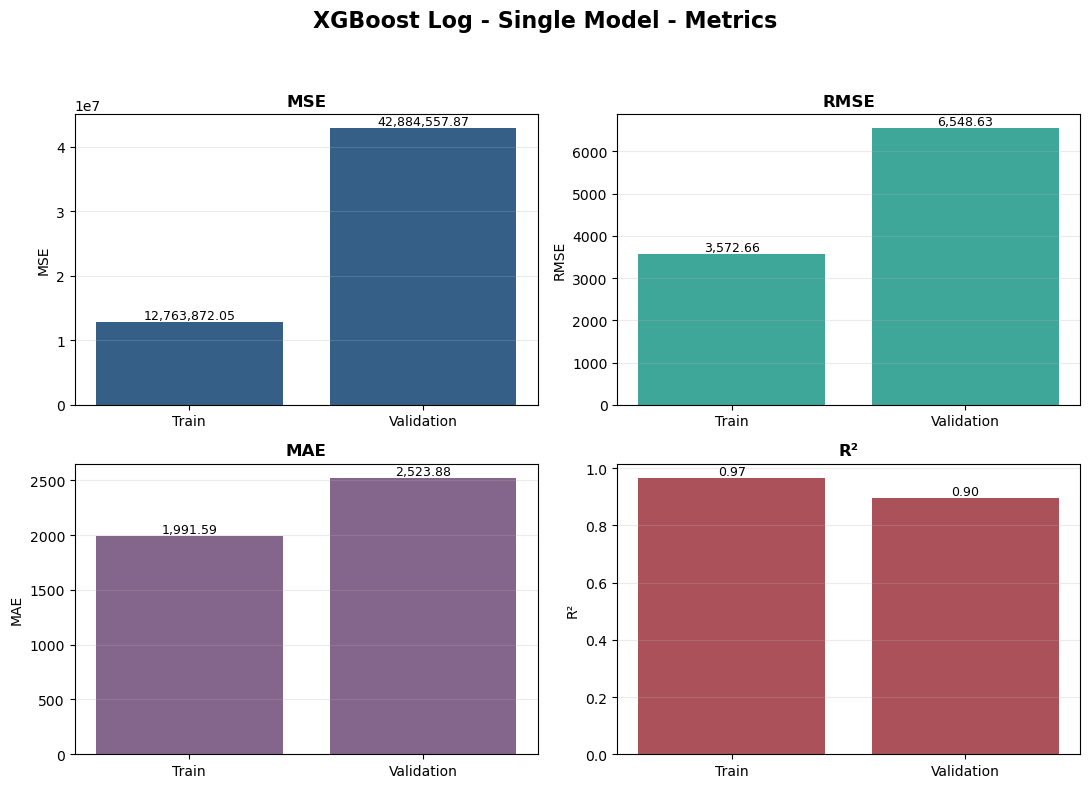

In [62]:
visual.plot_regression_metrics(
    xgboost_single_metrics,
    model_name="XGBoost Log - Single Model",

)


#### High-end split

Para la segunda estrategia, la separación se realiza desde el dataset preprocesado completo. Primero se divide `dataset_processed` en dos subconjuntos según si la marca pertenece al grupo de alta gama o no. Luego, dentro de cada subconjunto, se vuelve a hacer el split train/validation y recién después se aplica el one-hot encoding por separado.

De esta forma, cada modelo se entrena con un universo de categorías propio: el modelo de alta gama solo aprende categorías presentes en autos de alta gama, y el modelo del resto solo aprende categorías presentes en autos no alta gama.


In [63]:
TARGET = "Precio"

dataset_high_end_mask = dataset_processed["Marca"].isin(fe.DEFAULT_PREMIUM_BRANDS)

dataset_high_end = dataset_processed.loc[dataset_high_end_mask].copy()
dataset_regular = dataset_processed.loc[~dataset_high_end_mask].copy()

X_high_end = dataset_high_end.drop(columns=[TARGET])
y_high_end = dataset_high_end[TARGET]

X_regular = dataset_regular.drop(columns=[TARGET])
y_regular = dataset_regular[TARGET]

(X_train_high_end_raw, y_train_high_end), (X_val_high_end_raw, y_val_high_end) = split.train_val_split_stratified(
    X_high_end,
    y_high_end,
    stratify_by=X_high_end["Marca"],
    train_size=0.80,
    random_state=42,
)

(X_train_regular_raw, y_train_regular), (X_val_regular_raw, y_val_regular) = split.train_val_split_stratified(
    X_regular,
    y_regular,
    stratify_by=X_regular["Marca"],
    train_size=0.80,
    random_state=42,
)

version_feature_kwargs = {
    "source_col": "Versión",
    "tier_patterns": VERSION_TIER_PATTERNS,
    "binary_patterns": VERSION_BINARY_PATTERNS,
    "prefix": "Version",
    "default_tier": 1,
    "drop_source_col": True,
    "columns_to_drop": ["Título", "Descripción"],
}

X_train_high_end_segment, X_val_high_end_segment = fe.add_text_pattern_features_to_split(
    X_train_high_end_raw,
    X_val_high_end_raw,
    **version_feature_kwargs,
)

X_train_regular_segment, X_val_regular_segment = fe.add_text_pattern_features_to_split(
    X_train_regular_raw,
    X_val_regular_raw,
    **version_feature_kwargs,
)

split_size_summary = pd.DataFrame([
    {
        "split": "train",
        "high_end_rows": len(X_train_high_end_segment),
        "non_high_end_rows": len(X_train_regular_segment),
    },
    {
        "split": "validation",
        "high_end_rows": len(X_val_high_end_segment),
        "non_high_end_rows": len(X_val_regular_segment),
    },
])

split_size_summary.style.hide(axis="index")


split,high_end_rows,non_high_end_rows
train,1341,13238
validation,335,3309


In [64]:
XGBOOST_PARAMS = {
    "n_estimators": 500,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
}


In [65]:
X_train_high_end_encoded, high_end_categories_map = prep.one_hot_encoding(
    X_train_high_end_segment,
    categorical_cols=categorical_cols_to_encode,
    train=True,
    binary_missing_cols=["Con cámara de retroceso"],
)

X_val_high_end_encoded = prep.one_hot_encoding(
    X_val_high_end_segment,
    categorical_cols=categorical_cols_to_encode,
    train=False,
    categories_map=high_end_categories_map,
    binary_missing_cols=["Con cámara de retroceso"],
)

X_train_regular_encoded, regular_categories_map = prep.one_hot_encoding(
    X_train_regular_segment,
    categorical_cols=categorical_cols_to_encode,
    train=True,
    binary_missing_cols=["Con cámara de retroceso"],
)

X_val_regular_encoded = prep.one_hot_encoding(
    X_val_regular_segment,
    categorical_cols=categorical_cols_to_encode,
    train=False,
    categories_map=regular_categories_map,
    binary_missing_cols=["Con cámara de retroceso"],
)

pd.DataFrame([
    {
        "segment": "high_end",
        "train_shape": X_train_high_end_encoded.shape,
        "validation_shape": X_val_high_end_encoded.shape,
    },
    {
        "segment": "non_high_end",
        "train_shape": X_train_regular_encoded.shape,
        "validation_shape": X_val_regular_encoded.shape,
    },
])


,segment,train_shape,validation_shape
0,high_end,"(1341, 88)","(335, 88)"
1,non_high_end,"(13238, 180)","(3309, 180)"


#### Single model with high-end feature

Dado que el split por alta gama deja pocas observaciones en ese segmento, se prueba una alternativa extra más estable, en caso de que el split no funcione: mantener un único modelo para todo el dataset y agregar una variable binaria que indique si la marca pertenece al grupo de alta gama. De esta forma, el modelo conserva toda la información disponible y, al mismo tiempo, puede ajustar diferencias sistemáticas entre autos premium y no premium.


In [66]:
single_model_high_end_mask_train = X_train_fe["Marca"].isin(fe.DEFAULT_PREMIUM_BRANDS)
single_model_high_end_mask_val = X_val_fe["Marca"].isin(fe.DEFAULT_PREMIUM_BRANDS)

X_train_high_end_feature = X_train_encoded.copy()
X_val_high_end_feature = X_val_encoded.copy()

X_train_high_end_feature["Es_Alta_Gama"] = single_model_high_end_mask_train.astype(int)
X_val_high_end_feature["Es_Alta_Gama"] = single_model_high_end_mask_val.astype(int)

xgboost_high_end_feature_model, xgboost_high_end_feature_metrics, xgboost_high_end_feature_predictions = mod.train_xgboost(
    X_train_high_end_feature,
    y_train,
    X_val_high_end_feature,
    y_val,
    use_log_target=True,
    **XGBOOST_PARAMS,
)

xgboost_high_end_feature_metrics


,train_mse,val_mse,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2
0,1.175595e+07,4.019539e+07,3428.695645,6339.983464,1923.357257,2450.434983,0.969305,0.90344


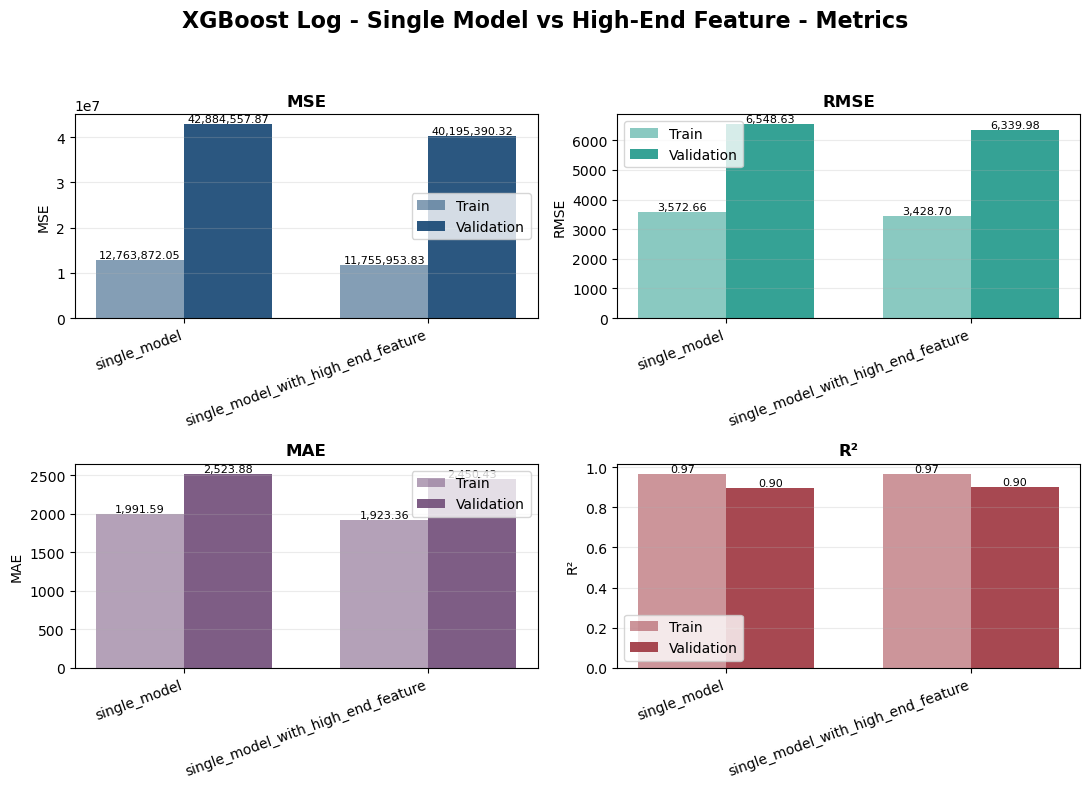

,train_mse,val_mse,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2,model
0,1.276387e+07,4.288456e+07,3572.656162,6548.630228,1991.589757,2523.879433,0.966674,0.896979,single_model
1,1.175595e+07,4.019539e+07,3428.695645,6339.983464,1923.357257,2450.434983,0.969305,0.903440,single_model_with_high_end_feature


In [67]:
high_end_feature_comparison = pd.concat(
    [
        xgboost_single_metrics.assign(model="single_model"),
        xgboost_high_end_feature_metrics.assign(model="single_model_with_high_end_feature"),
    ],
    ignore_index=True,
)

visual.plot_regression_metrics(
    high_end_feature_comparison,
    model_name="XGBoost Log - Single Model vs High-End Feature",
    label_col="model",
)

high_end_feature_comparison


#### High-end model

Primero se entrena un XGBoost usando solamente las observaciones de marcas consideradas de alta gama.


In [68]:
xgboost_high_end_model, xgboost_high_end_metrics, xgboost_high_end_predictions = mod.train_xgboost(
    X_train_high_end_encoded,
    y_train_high_end,
    X_val_high_end_encoded,
    y_val_high_end,
    use_log_target=True,
    **XGBOOST_PARAMS,
)

xgboost_high_end_metrics


,train_mse,val_mse,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2
0,7.072991e+06,2.427391e+08,2659.509492,15580.085862,1634.514812,6274.944196,0.995577,0.889585


#### "Rest" model

Luego se entrena otro XGBoost independiente con el resto de las observaciones. De esta forma, el modelo segmentado queda compuesto por dos modelos distintos.


In [69]:
xgboost_regular_model, xgboost_regular_metrics, xgboost_regular_predictions = mod.train_xgboost(
    X_train_regular_encoded,
    y_train_regular,
    X_val_regular_encoded,
    y_val_regular,
    use_log_target=True,
    **XGBOOST_PARAMS,
)

xgboost_regular_metrics


,train_mse,val_mse,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2
0,8.296524e+06,1.148423e+07,2880.368656,3388.839212,1609.003022,1872.238582,0.947181,0.930036


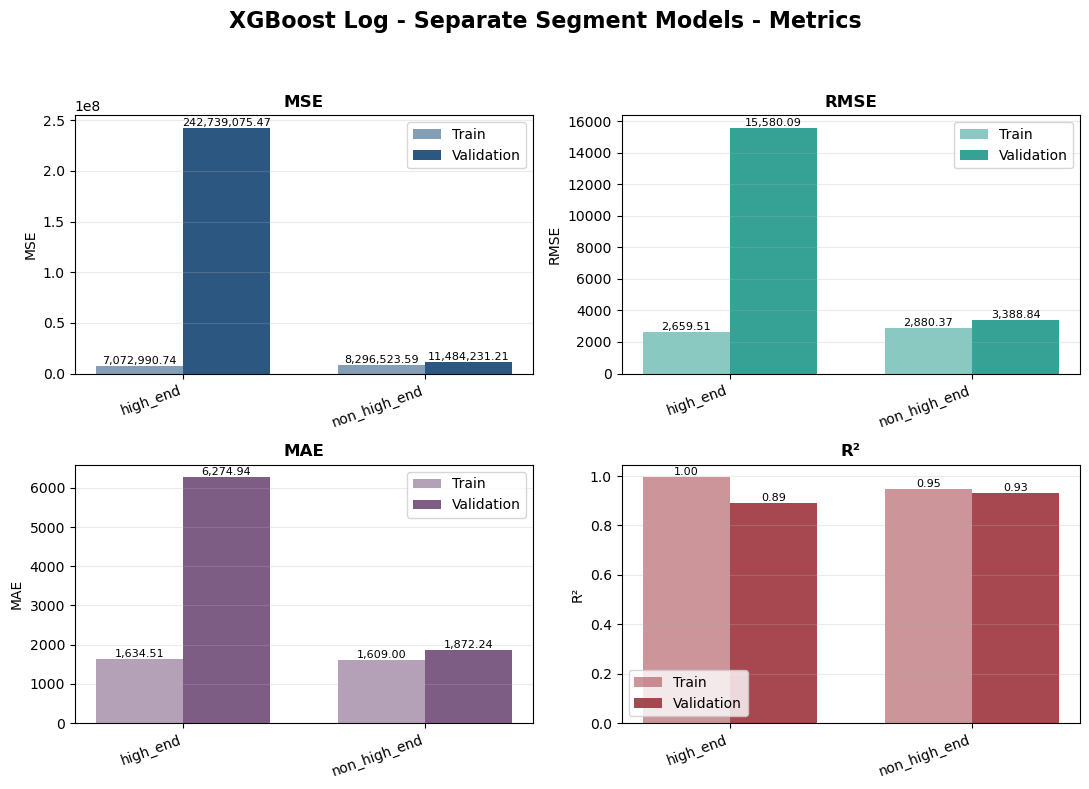

In [70]:
xgboost_segment_metrics = pd.concat(
    [
        xgboost_high_end_metrics.assign(segment="high_end"),
        xgboost_regular_metrics.assign(segment="non_high_end"),
    ],
    ignore_index=True,
)

visual.plot_regression_metrics(
    xgboost_segment_metrics,
    model_name="XGBoost Log - Separate Segment Models",
    label_col="segment",
)


##### Analizando resultados

Claramente se observa como, si bien el modelo resto mejora mucho la aperformance, el modelo de alta gama empeora mucho, veamos que estpá ocurrinedo

In [71]:
pd.DataFrame([
    {
        "segment": "high_end",
        "train_count": len(X_train_high_end_segment),
        "val_count": len(X_val_high_end_segment),
    },
    {
        "segment": "non_high_end",
        "train_count": len(X_train_regular_segment),
        "val_count": len(X_val_regular_segment),
    },
])


,segment,train_count,val_count
0,high_end,1341,335
1,non_high_end,13238,3309


In [72]:
high_end_price_summary = (
    X_train_high_end_raw
    .assign(Precio=y_train_high_end)
    .groupby(["Marca", "Modelo"])["Precio"]
    .agg(count="count", median="median", mean="mean", min="min", max="max")
    .sort_values("max", ascending=False)
)

high_end_price_summary.head(20)


count         median           mean  \
Marca         Modelo                                                   
land rover    range rover sport     15   69000.000000   97653.333333   
bmw           x6                   118   59950.000000   75936.892565   
porsche       macan                 19  105000.000000  135205.210526   
              cayenne               34   45950.000000   63141.117647   
mercedes benz clase gle             27   84000.000000  101929.629630   
bmw           x3                    72   51450.000000   56680.826165   
              x5                    61   40000.000000   57506.459016   
audi          q8                    20  151500.000000  149515.000000   
              q7                    40   92500.000000   96417.579705   
mercedes benz clase glc             88   55000.000000   62881.238636   
audi          q5 sportback          21  102000.000000  102700.000000   
land rover    discovery              8   32700.000000   40087.500000   
porsche       panamera               1  119000.000000  119000.000000   
volvo         xc60                  26   44227.249002   52244.403769   
bmw           x4                    35   48000.000000   55493.685714   
              x2                    31   58000.000000   62890.000000   
land rover    evoque                20   39400.000000   43389.900000   
bmw           serie 4                4   71200.000000   72825.000000   
mercedes benz clase gla             65   33900.000000   40940.287759   
bmw           x1                   215   33900.000000   37733.430099   

                                           min       max  
Marca         Modelo                                      
land rover    range rover sport   26000.000000  315000.0  
bmw           x6                  24000.000000  268900.0  
porsche       macan               78000.000000  268000.0  
              cayenne             22900.000000  259000.0  
mercedes benz clase gle           57500.000000  215000.0  
bmw           x3                  11500.000000  198000.0  
              x5                  10900.000000  189000.0  
audi          q8                 115000.000000  185000.0  
              q7                  17000.000000  180000.0  
mercedes benz clase glc           34500.000000  140000.0  
audi          q5 sportback        88000.000000  127000.0  
land rover    discovery            8600.000000  124900.0  
porsche       panamera           119000.000000  119000.0  
volvo         xc60                13000.000000  114900.0  
bmw           x4                  34500.000000  113000.0  
              x2                  42500.000000  103000.0  
land rover    evoque              19000.000000  100000.0  
bmw           serie 4             51900.000000   97000.0  
mercedes benz clase gla           23500.000000   90000.0  
bmw           x1                  12035.615597   89900.0

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Feature Diagnostics
</h3>


Luego de entrenar, revisamos si las variables creadas tienen cobertura suficiente y si el modelo efectivamente las utiliza. Esto ayuda a decidir si vale la pena conservarlas en el pipeline final.


In [73]:
version_feature_cols = [
    "Version_Tier",
    "Version_Tier_Unknown",
    "Version_4x4",
    "Version_Sport",
    "Version_Extra",
]

X_val_fe[version_feature_cols].mean().sort_values(ascending=False)


Version_Tier            1.325741
Version_Tier_Unknown    0.302964
Version_4x4             0.180296
Version_Extra           0.088913
Version_Sport           0.086169
dtype: float64

In [74]:
diagnostic_data = X_train_fe.copy()
diagnostic_data["Precio"] = y_train

(
    diagnostic_data
    .groupby("Version_Tier")["Precio"]
    .agg(
        count="count",
        median="median",
        mean="mean",
    )
    .sort_index()
)


,count,median,mean
Version_Tier,,,
0,943,20709.855695,21210.023943
1,8603,22500.000000,27572.068604
2,4516,26392.385631,28284.443357
3,517,29229.352165,40042.653852


In [75]:
(
    diagnostic_data
    .groupby(["Marca", "Modelo", "Version_Tier"])["Precio"]
    .agg(
        count="count",
        median="median",
    )
    .reset_index()
    .sort_values(["Marca", "Modelo", "Version_Tier"])
)


,Marca,Modelo,Version_Tier,count,median
0,alfa romeo,stelvio,1,20,83000.000000
1,audi,q2,1,56,49150.000000
2,audi,q3,1,88,40202.640467
3,audi,q3 sportback,1,33,62000.000000
4,audi,q5,1,159,31000.000000
...,...,...,...,...,...
227,volkswagen,touareg,1,7,25000.000000
228,volkswagen,touareg,3,7,22500.000000
229,volvo,xc40,1,4,60450.000000
230,volvo,xc60,1,24,44227.249002


In [76]:
feature_importance = pd.Series(
    xgboost_single_model.named_steps["regressor"].feature_importances_,
    index=X_train_encoded.columns,
).sort_values(ascending=False)

feature_importance.head(30)


Transmisión_manual      0.180257
Modelo_corolla cross    0.045993
Marca_bmw               0.033480
Cilindrada              0.032233
Marca_audi              0.027402
Modelo_wrangler         0.025538
Modelo_clase glc        0.022354
Modelo_c4 cactus        0.021374
Modelo_tracker          0.021186
Marca_mercedes benz     0.020819
Año                     0.020357
Modelo_journey          0.019567
Marca_fiat              0.018907
Marca_porsche           0.018714
Marca_toyota            0.018108
Version_4x4             0.018032
Marca_renault           0.017778
Modelo_x6               0.014159
Modelo_ecosport         0.013762
Modelo_x1               0.013088
Modelo_clase gla        0.012868
Marca_ford              0.010568
Marca_citroen           0.009278
Marca_volkswagen        0.008826
Marca_chery             0.008475
Marca_dodge             0.008329
Kilómetros              0.008274
Modelo_tiggo            0.008234
Marca_land rover        0.007944
Marca_jeep              0.007895
dtype: flo

In [77]:
feature_importance[feature_importance.index.str.contains("Version")]


Version_4x4             0.018032
Version_Tier_Unknown    0.005568
Version_Sport           0.002345
Version_Tier            0.002126
Version_Extra           0.001551
dtype: float32

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Error Analysis
</h3>


In [78]:
prediction_context = mod.attach_prediction_context(
    xgboost_single_predictions,
    X_train_fe,
    X_val_fe,
)

mod.top_prediction_errors(
    prediction_context,
    split="validation",
    n=20,
).style.hide(axis="index")


split,row_index,Marca,Modelo,Año,Kilómetros,Cilindrada,Transmisión,Tipo de combustible,Color,Tipo de vendedor,Con cámara de retroceso,y_true,y_pred,residual,abs_error,signed_pct_error,abs_pct_error
validation,3335,porsche,cayenne,2022.000000,14000,4.000000,automatica,nafta,gris,tienda,1.000000,345000.000000,154017.953125,190982.046875,190982.046875,55.357115,55.357115
validation,2938,volkswagen,nivus,2024.000000,0,1.000000,automatica,nafta,gris,concesionaria,nan,150000.000000,29660.962891,120339.037109,120339.037109,80.226025,80.226025
validation,2516,bmw,x5,2024.000000,11972,3.000000,automatica,nafta,gris,concesionaria,nan,249000.000000,139317.062500,109682.937500,109682.937500,44.049372,44.049372
validation,2723,alfa romeo,stelvio,2024.000000,0,3.000000,automatica,nafta,negro,concesionaria,nan,230000.000000,122114.640625,107885.359375,107885.359375,46.906678,46.906678
validation,1890,bmw,x3,2021.000000,13500,3.000000,automatica,nafta,gris,concesionaria,nan,198000.000000,110110.851562,87889.148438,87889.148438,44.388459,44.388459
validation,762,bmw,x3,2019.000000,5000,2.000000,automatica,nafta,azul,particular,1.000000,133000.000000,77216.554688,55783.445312,55783.445312,41.942440,41.942440
validation,651,chevrolet,equinox,2020.000000,87,1.500000,automatica,nafta,blanco,concesionaria,nan,85968.681977,31900.826172,54067.855805,54067.855805,62.892503,62.892503
validation,1960,jeep,grand cherokee,2019.000000,47000,6.400000,automatica,nafta,rojo,particular,nan,125000.000000,75892.859375,49107.140625,49107.140625,39.285712,39.285712
validation,801,bmw,x3,2021.000000,32000,3.000000,automatica,nafta,negro,particular,nan,70000.000000,112354.812500,-42354.812500,42354.812500,-60.506875,60.506875
validation,909,bmw,x3,2019.000000,49000,2.000000,automatica,nafta,negro,particular,1.000000,99990.000000,58971.023438,41018.976562,41018.976562,41.023079,41.023079


In [79]:
mod.summarize_prediction_errors(
    prediction_context,
    group_cols=["Marca", "Modelo"],
    split="validation",
    min_count=5,
).head(20).style.hide(axis="index")


Marca,Modelo,count,mae,median_abs_error,rmse,mean_residual,median_y_true,median_y_pred,mean_abs_pct_error,bias_direction
porsche,cayenne,10,26004.383008,7354.649414,60966.597968,23343.069727,43500.000000,39079.177734,21.540825,underprediction
alfa romeo,stelvio,5,25910.400000,5710.882812,48495.849496,23921.115625,74000.000000,67429.109375,16.687755,underprediction
audi,q8,5,17626.143750,14333.468750,20200.103608,12924.912500,177000.000000,172601.140625,9.977154,underprediction
bmw,x3,22,15461.752308,5288.932617,26776.226190,6423.346058,57000.000000,59244.855469,20.049313,underprediction
bmw,x2,6,12696.263021,7075.970703,18597.283139,9645.945312,73950.000000,62076.285156,14.455976,underprediction
bmw,x5,18,11802.213542,2782.757812,27964.798932,8881.703342,34850.000000,37018.238281,13.261318,underprediction
mercedes benz,clase gle,10,11151.219531,7532.232422,14533.593797,10162.024219,77500.000000,71389.582031,12.693857,underprediction
mercedes benz,clase glc,22,10932.951882,6681.937500,14991.087081,5629.702592,57650.000000,57073.810547,14.568880,underprediction
chevrolet,equinox,10,8080.702149,2637.034505,17450.883669,5268.236466,26990.067547,27605.300781,15.758494,underprediction
toyota,land cruiser,11,7459.454023,3831.214844,9971.204793,6437.689109,40000.000000,29569.535156,16.496355,underprediction
